In [20]:
here::i_am("rna/regression/regress_variables.R")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

# Multi core using future - built in to seurat
plan("multicore", workers = 24)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

args = list()
args$rna_metadata = file.path(io$basedir, 'results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz')
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')
args$rna_nfeatures = 2500
args$vars_to_regress = c("nFeature_RNA", "nCount_RNA", "mitochondrial_percent_RNA", "ribosomal_percent_RNA")

args$outdir = file.path(io$basedir, 'results/rna/regression/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [2]:
metadata_rna <- fread(args$rna_metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>% 
  .[,exp := str_replace_all(sample, opts$sample2exp)]

In [5]:
##############################
## Load RNA expression data ##
##############################

rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = metadata_rna$cell)

# Add sample metadata to the colData of the SingleCellExperiment
colData(rna.sce) <- metadata_rna %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(rna.sce),] %>% DataFrame()

# Filter features manually
rna.sce <- rna.sce[grep("*Rik|^Gm|^Mt-|^Rps|^Rpl|^Olfr",rownames(rna.sce), invert=T),]

# Feature selection
rna_features <- modelGeneVar(rna.sce, block=metadata_rna$exp, BPPARAM = BPPARAM) %>% as.data.table(keep.rownames = T) %>%
  setnames("rn","gene") %>%
  .[mean>=0.001] %>% setorder(-p.value) #%>% head(args$rna_nfeatures) 



Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [21]:
# Feature selection
rna_features <- modelGeneVar(rna.sce, block=metadata_rna$exp, BPPARAM = BPPARAM) %>% as.data.table(keep.rownames = T) %>%
  setnames("rn","gene") %>%
  .[mean>=0.001] %>% setorder(FDR) %>% head(args$rna_nfeatures) %>% .$gene

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [22]:
rna.seurat = as.Seurat(rna.sce)

In [24]:
args$rna_npcs = 25

In [25]:
##################################
## RNA dimensionality reduction ##
##################################
rna.seurat <- ScaleData(rna.seurat, 
                    features = rna_features,
                    vars.to.regress = args$vars_to_regress,
                    verbose = FALSE)

rna.seurat <- RunPCA(rna.seurat, features = rna_features, npcs = args$rna_npcs, verbose = FALSE)

# Save PCA coordinates
rna_pca.dt <- rna.seurat@reductions[["pca"]]@cell.embeddings %>% round(3) %>% as.data.table(keep.rownames = T) %>% setnames("rn","cell")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


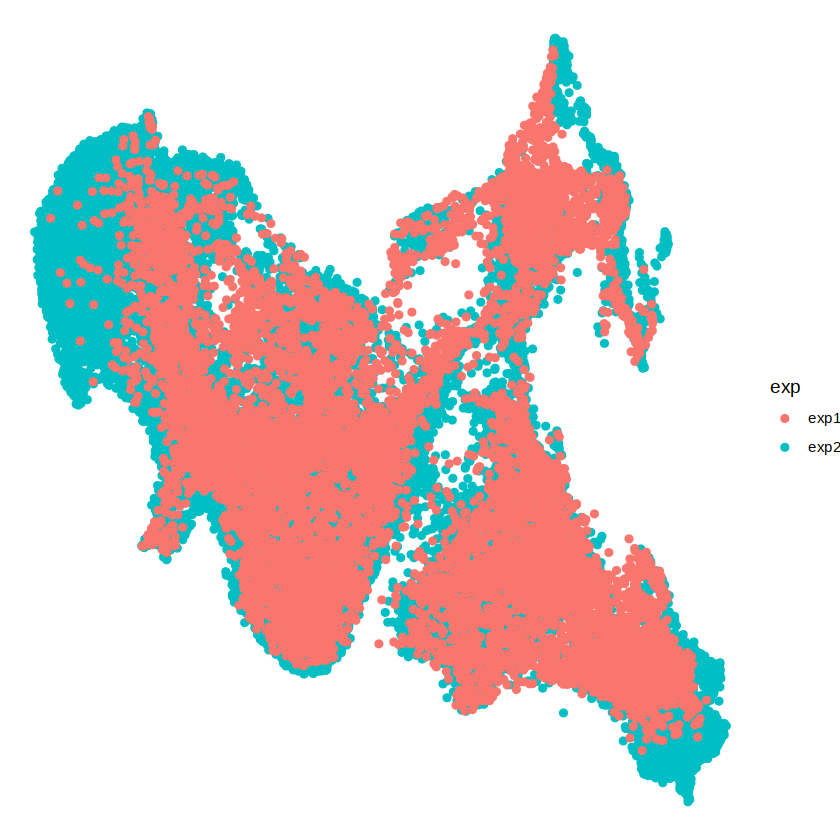

In [26]:
rna.seurat <- RunUMAP(rna.seurat, 
  dims = 1:args$rna_npcs,
  reduction = "pca",
  n.neighbors = 25,
  min.dist = 0.3,
  verbose=FALSE
)

# Fetch UMAP coordinates
umap.dt <- rna.seurat@reductions[["umap"]]@cell.embeddings %>% round(3) %>% as.data.table %>% 
  .[,cell:=colnames(rna.seurat)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>% 
  .[,c("cell","UMAP1","UMAP2")] %>%
  merge(.,metadata_rna, by='cell')

# Plot umap
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point() + 
    theme_void()


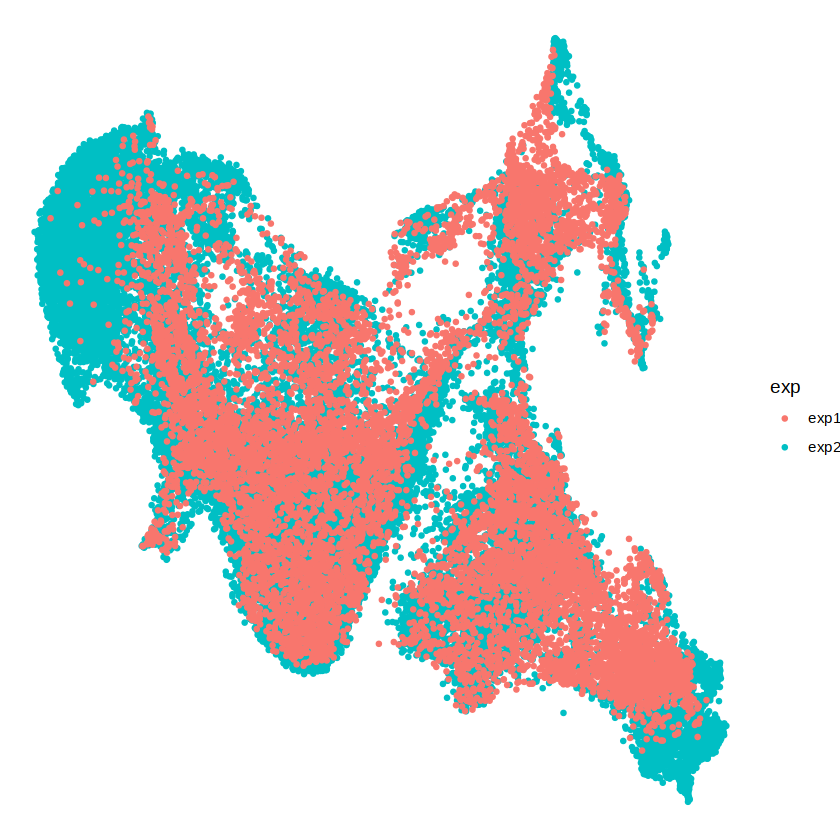

In [27]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point(size=0.8) + 
    theme_void()

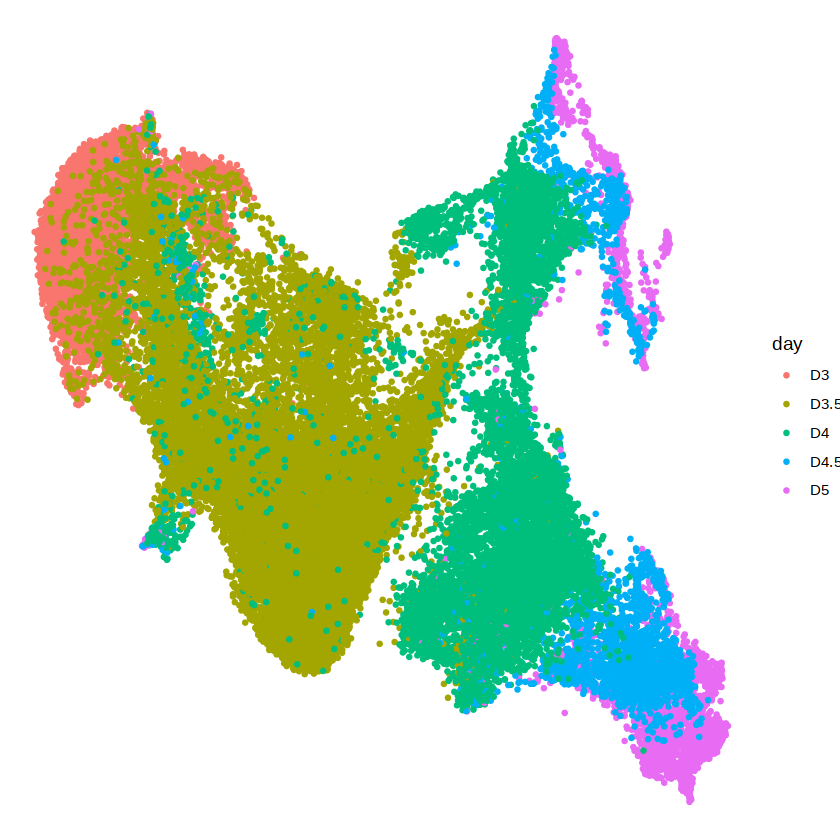

In [34]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=day)) + 
    geom_point(size=0.8) + 
    theme_void()

In [28]:
head(metadata_rna)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,pass_rnaQC,doublet_score,doublet_call,exp
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,6110,22923,6.09,10.15,day3_wt_rep1,D3,wt,TRUE,1.15,FALSE,exp2
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,4201,10794,6.57,7.38,day3_wt_rep1,D3,wt,TRUE,0.53,FALSE,exp2
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,3659,8745,5.74,11.92,day3_wt_rep1,D3,wt,TRUE,0.31,FALSE,exp2
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,3640,8461,3.70,7.21,day3_wt_rep1,D3,wt,TRUE,0.16,FALSE,exp2
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,3632,8276,4.60,8.16,day3_wt_rep1,D3,wt,TRUE,0.21,FALSE,exp2
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,4878,15676,7.34,8.97,day3_wt_rep1,D3,wt,TRUE,0.64,FALSE,exp2


In [130]:
regress_test = function(regress_variables){

    rna.seurat <- ScaleData(rna.seurat, 
                        features = rna_features,
                        vars.to.regress = regress_variables,
                        verbose = FALSE)

    rna.seurat <- RunPCA(rna.seurat, features = rna_features, npcs = args$rna_npcs, verbose = FALSE)

    rna.seurat <- RunUMAP(rna.seurat, 
      dims = 1:args$rna_npcs,
      reduction = "pca",
      n.neighbors = 25,
      min.dist = 0.3,
      verbose=FALSE
    )

    # Fetch UMAP coordinates
    umap.dt <- rna.seurat@reductions[["umap"]]@cell.embeddings %>% round(3) %>% as.data.table %>% 
      .[,cell:=colnames(rna.seurat)] %>%
      setnames(c("UMAP1","UMAP2","cell")) %>% 
      .[,c("cell","UMAP1","UMAP2")] %>%
      merge(.,metadata_rna, by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
        geom_point(size=0.6) + 
        theme_void()   
    if(length(regress_variables)==1)
        p1 = p1 + ggtitle(regress_variables)
    if(length(regress_variables)>=2){
        p1 = p1 + ggtitle(paste(regress_variables, collapse='-'))
    }
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=day)) + 
        geom_point(size=0.6) + 
        ggtitle('') + 
        theme_void()   
    ggarrange(p1, p2)
    }

In [101]:
regress_params = list(NULL,
                  c("nFeature_RNA", "nCount_RNA", "mitochondrial_percent_RNA", "ribosomal_percent_RNA"),
                  c("nFeature_RNA", "nCount_RNA", "mitochondrial_percent_RNA"),
                  c("nFeature_RNA", "nCount_RNA"),
                  c("nCount_RNA"),
                  c("nFeature_RNA"),
                  c("nCount_RNA", "mitochondrial_percent_RNA"))

In [121]:
length(NULL)

[1] 0

In [113]:
options(repr.plot.width=20, repr.plot.height=7)


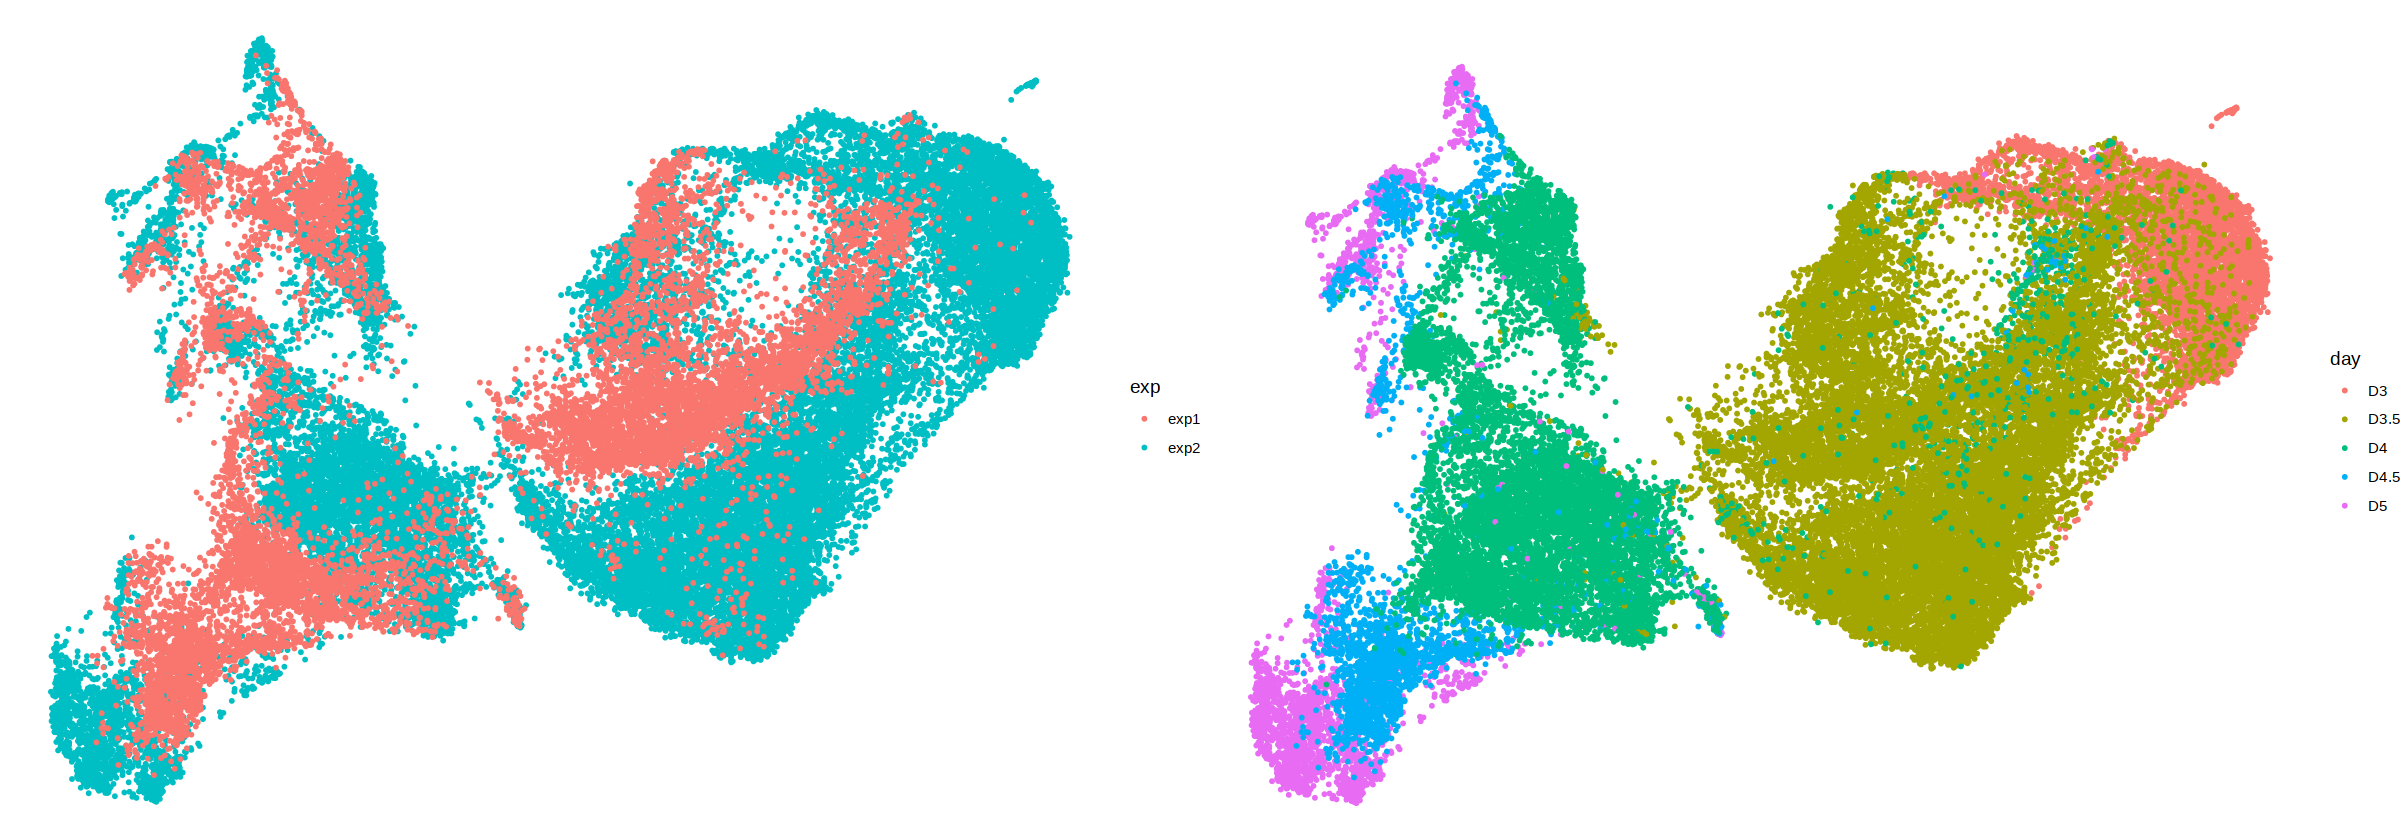

In [119]:
regress_test(NULL)

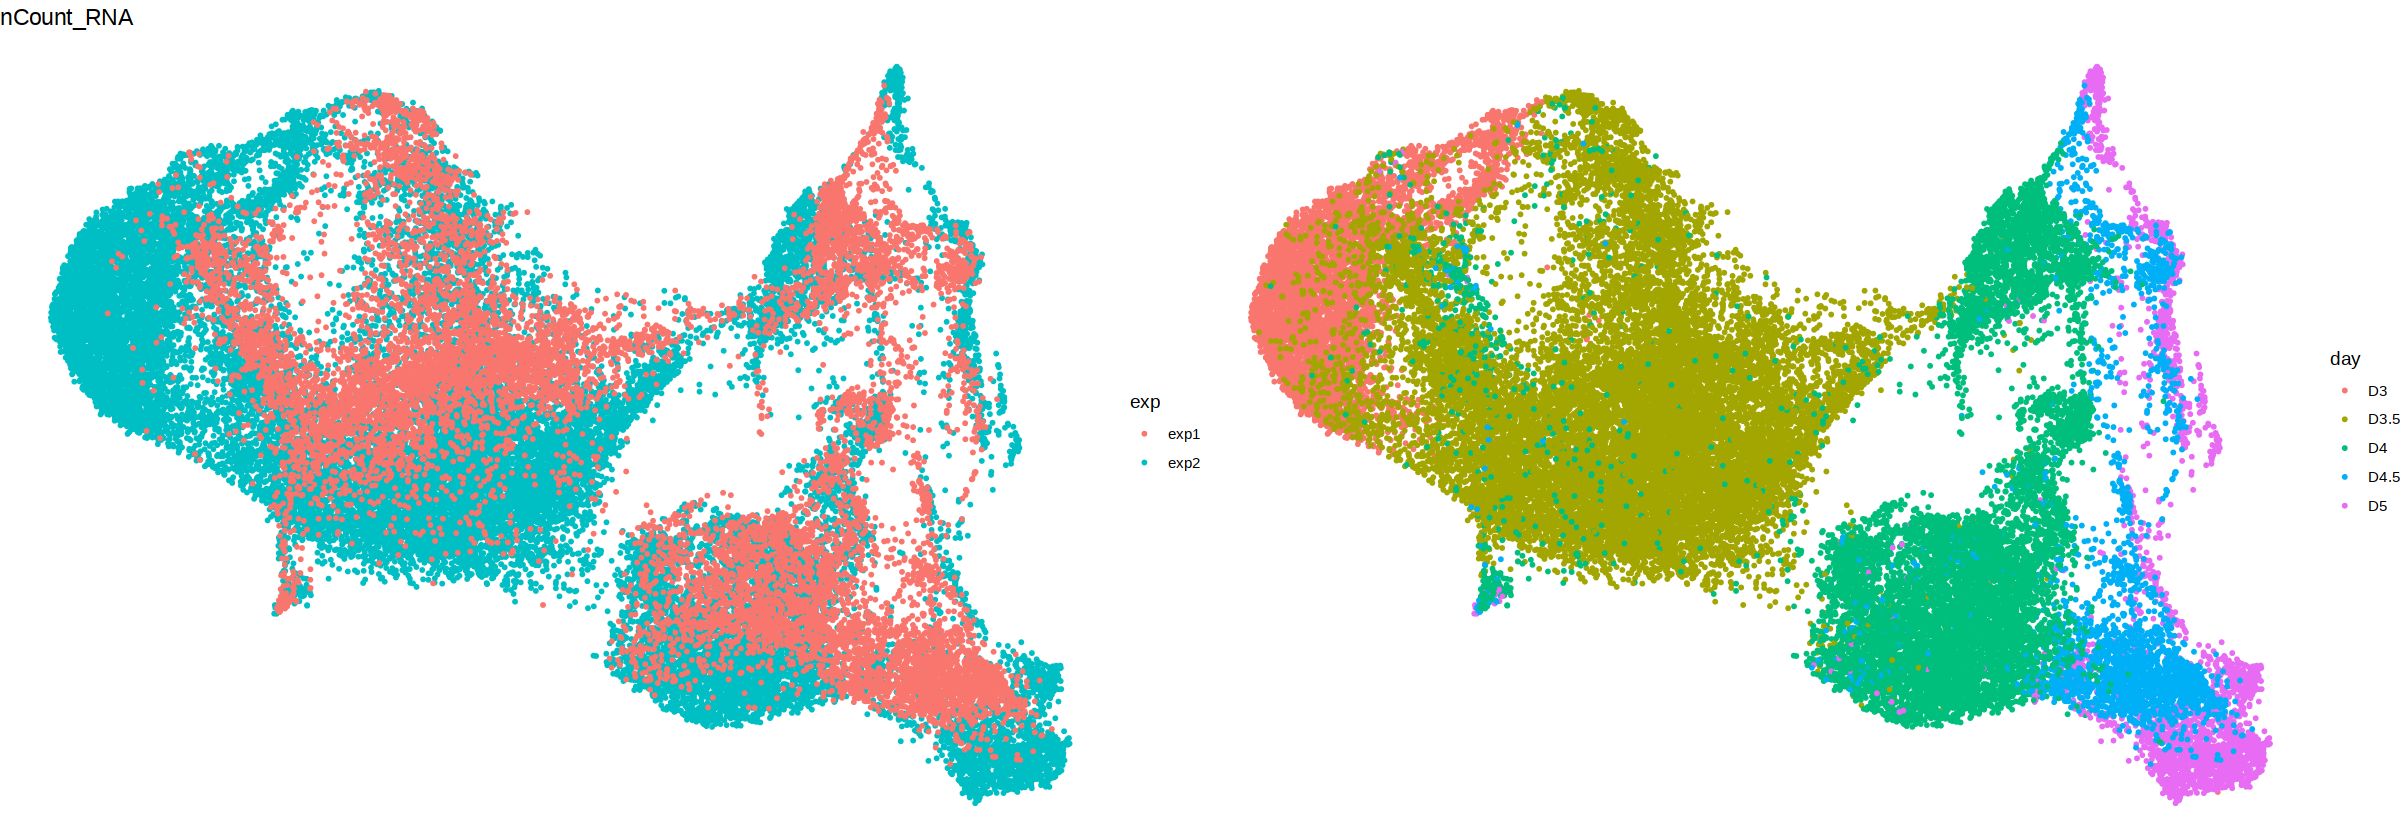

In [123]:
regress_test(c("nCount_RNA"))

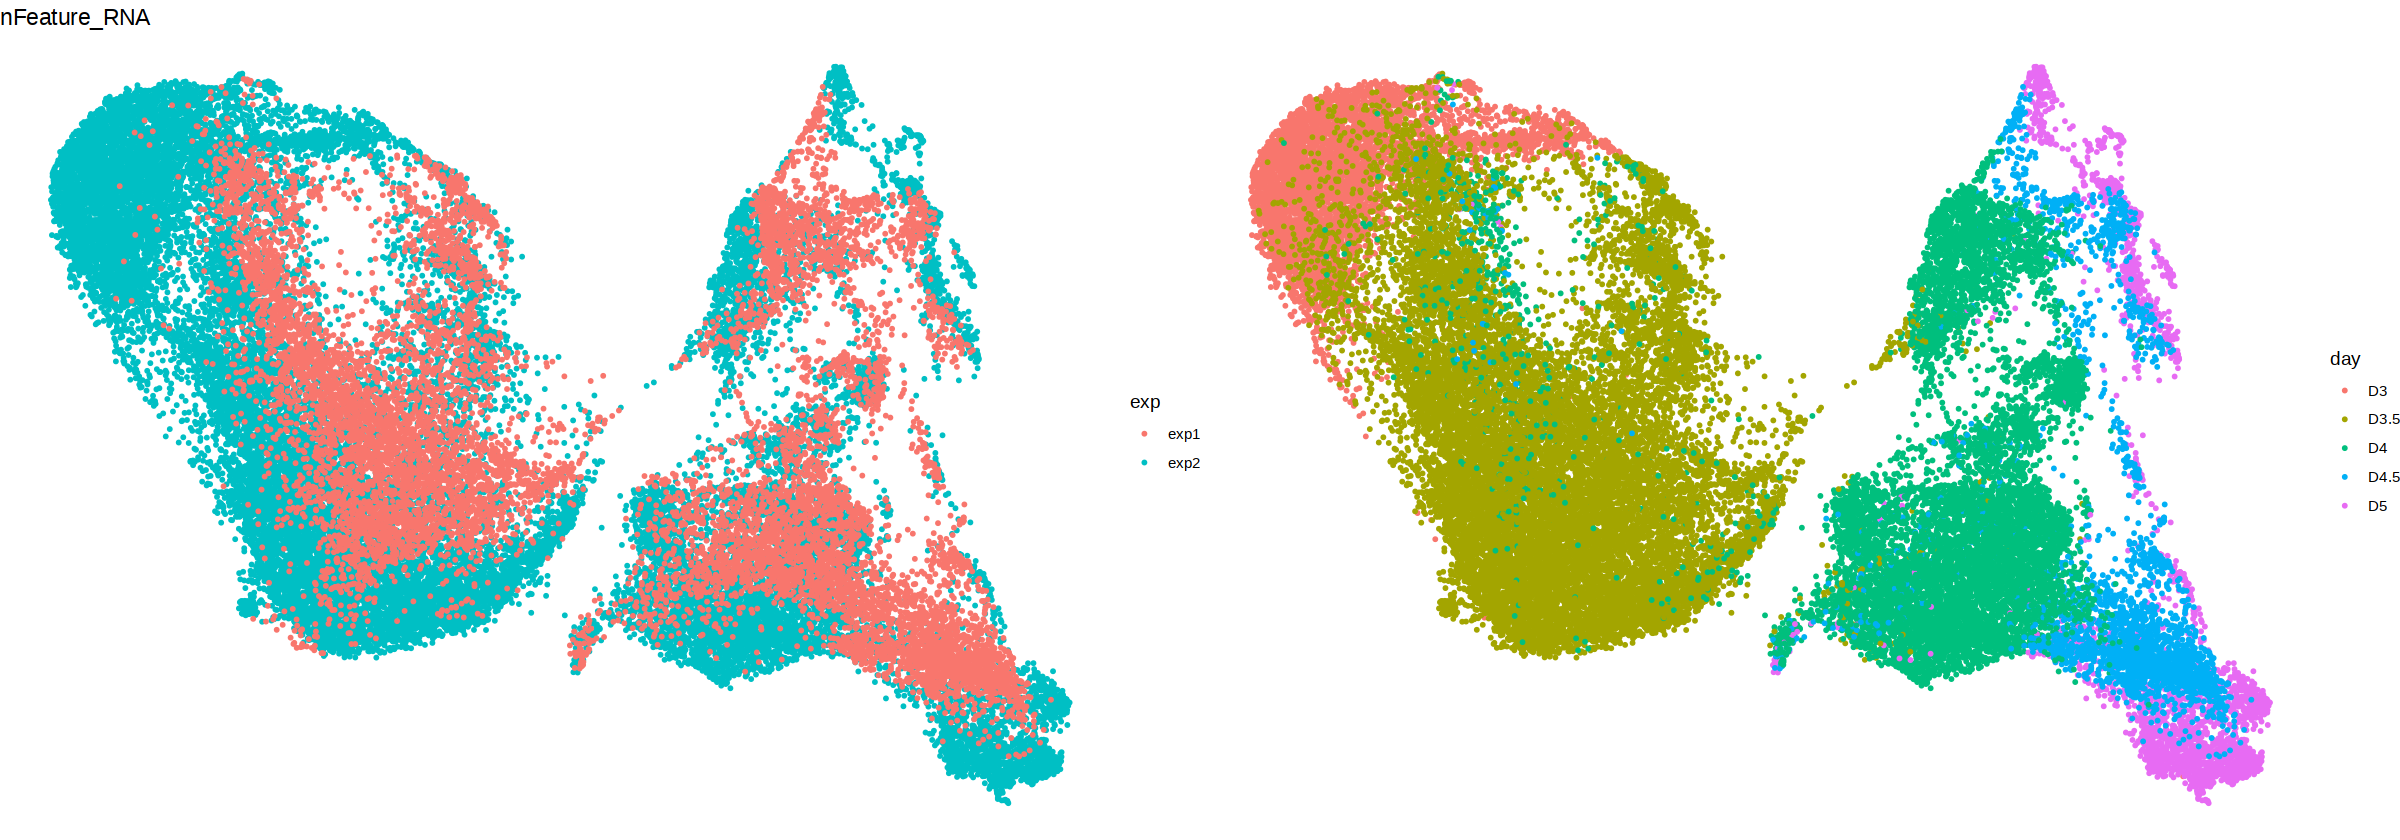

In [124]:
regress_test(c("nFeature_RNA"))

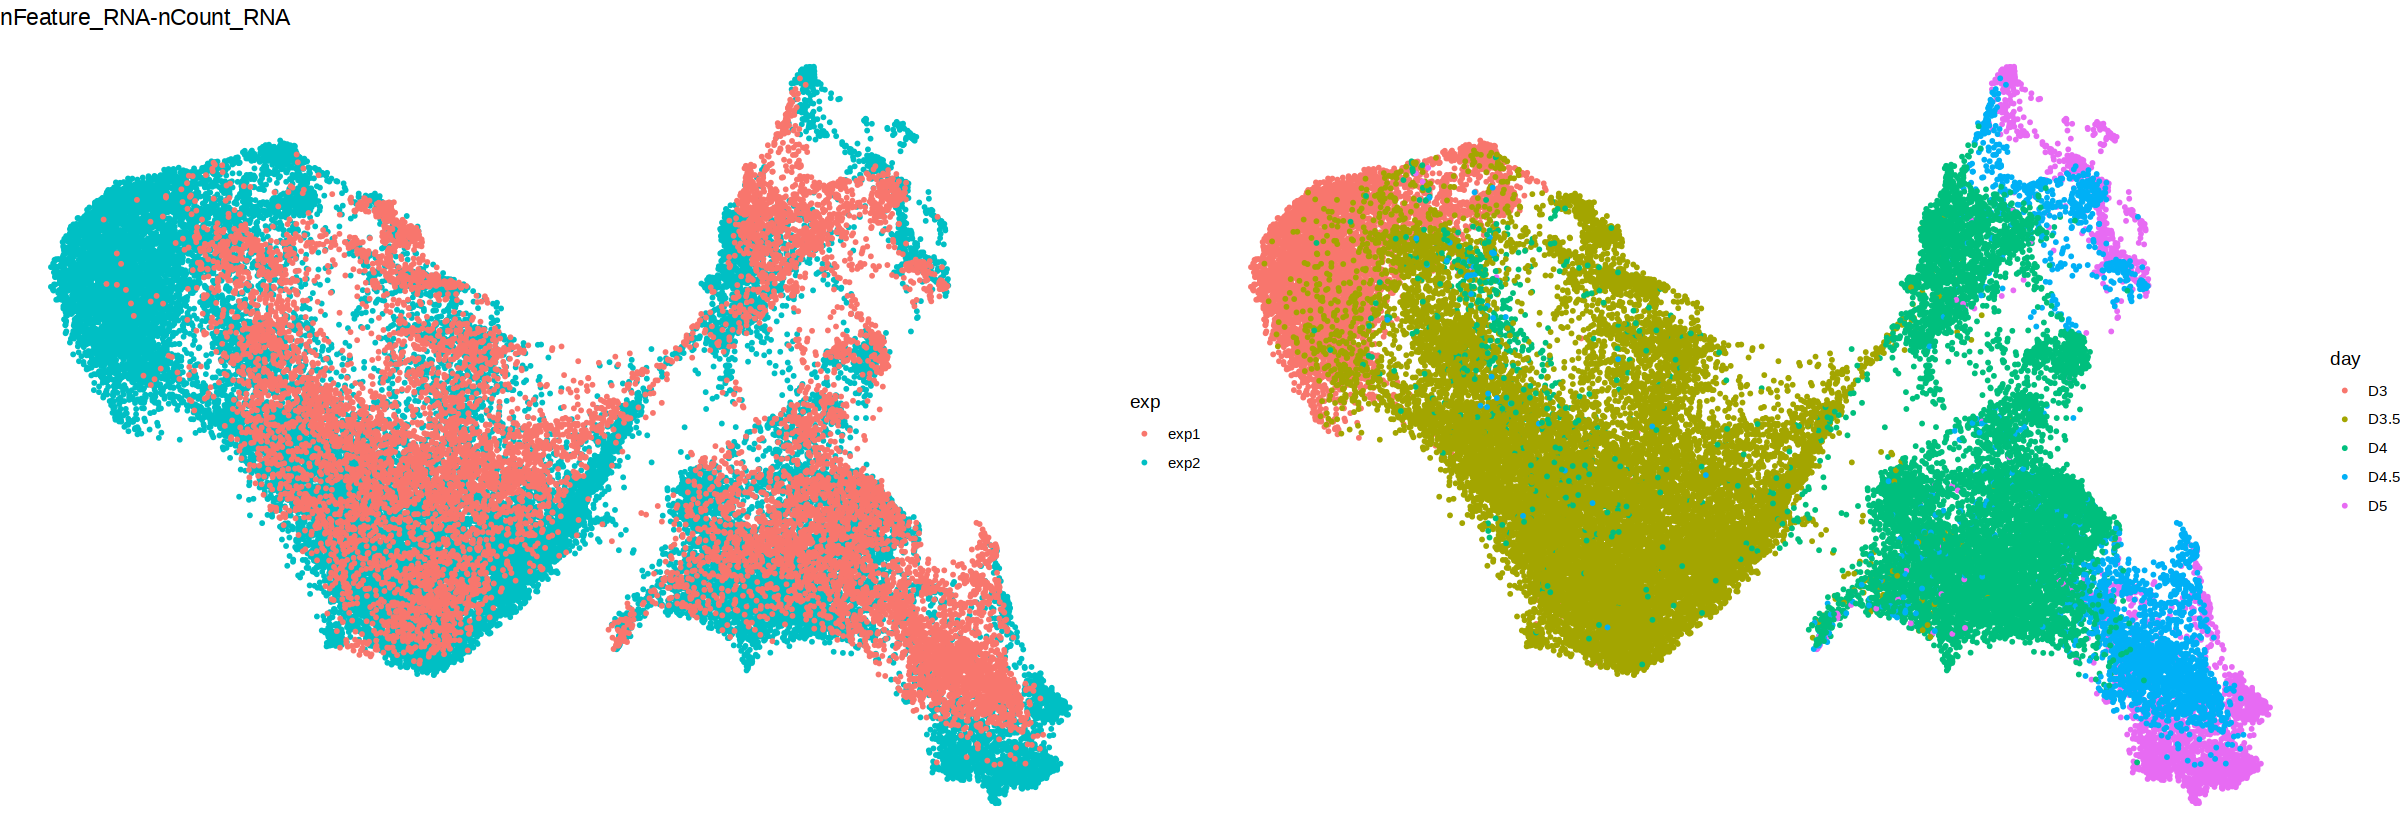

In [134]:
regress_test(c("nFeature_RNA", "nCount_RNA"))

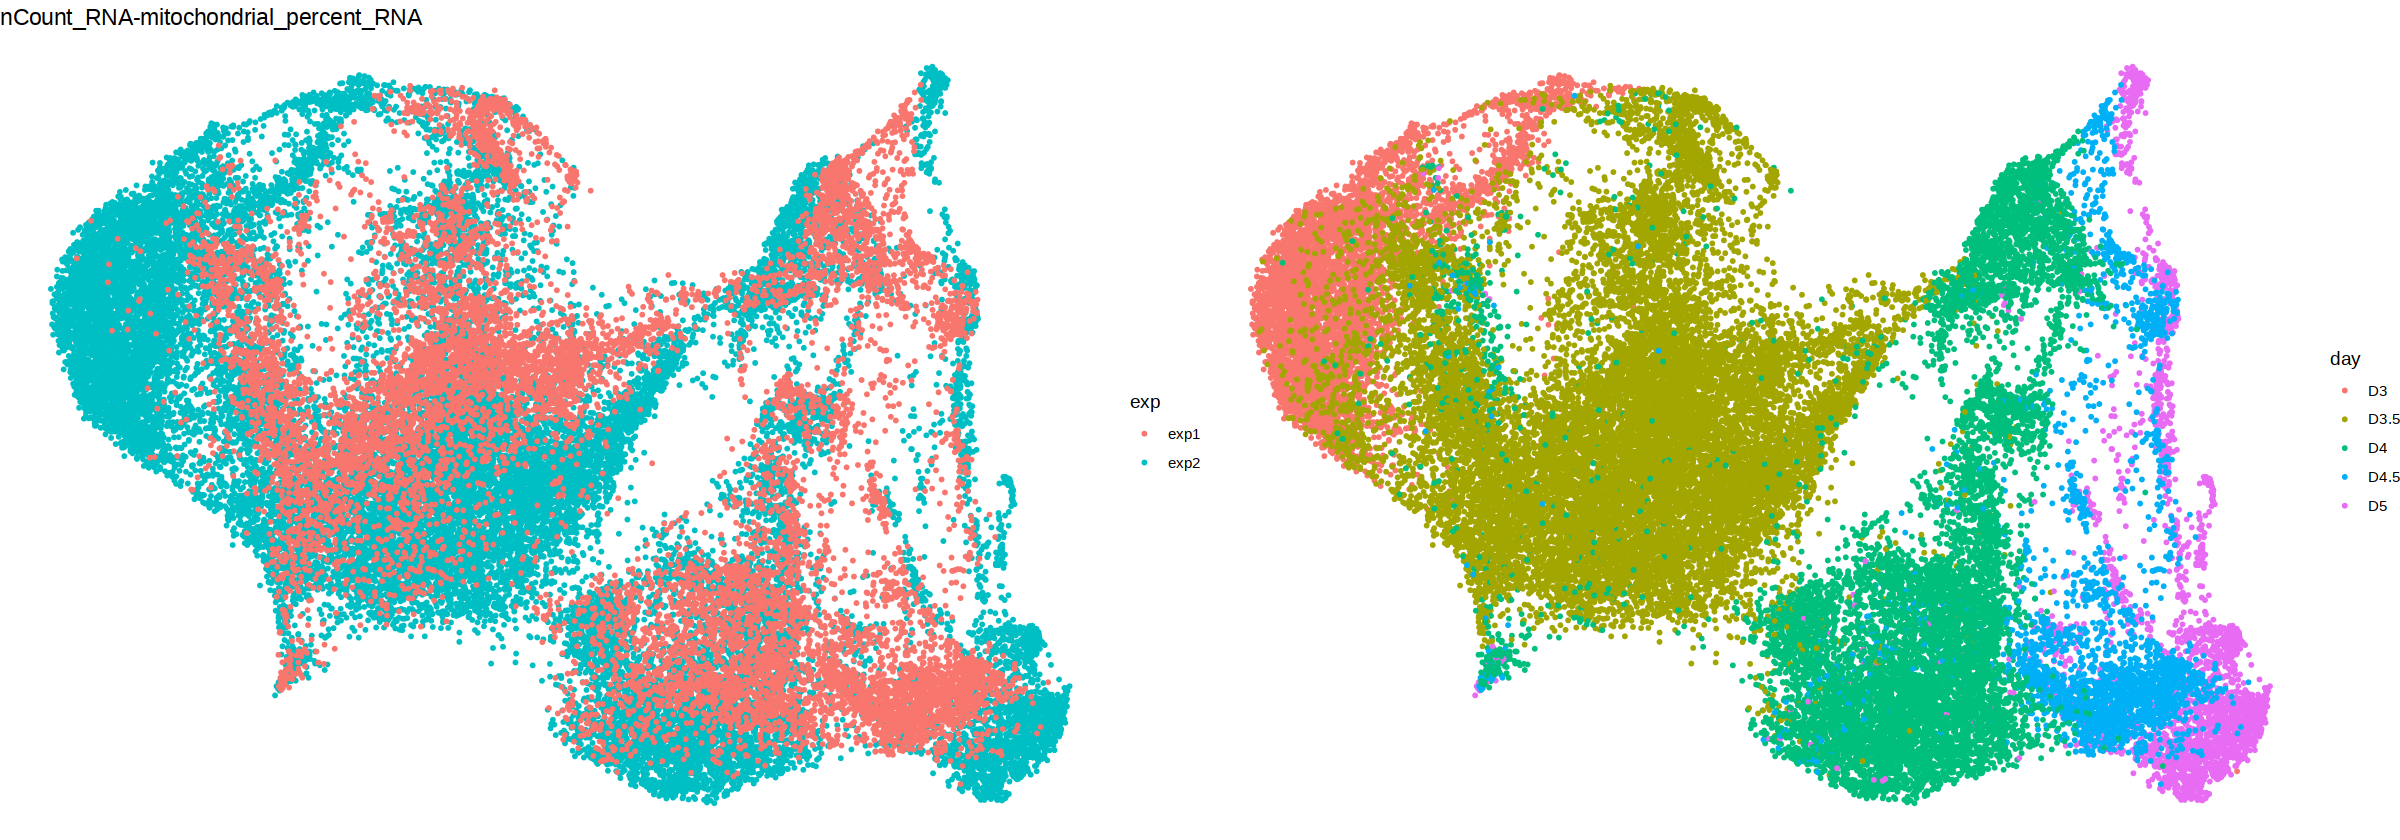

In [135]:
regress_test(c("nCount_RNA", "mitochondrial_percent_RNA"))

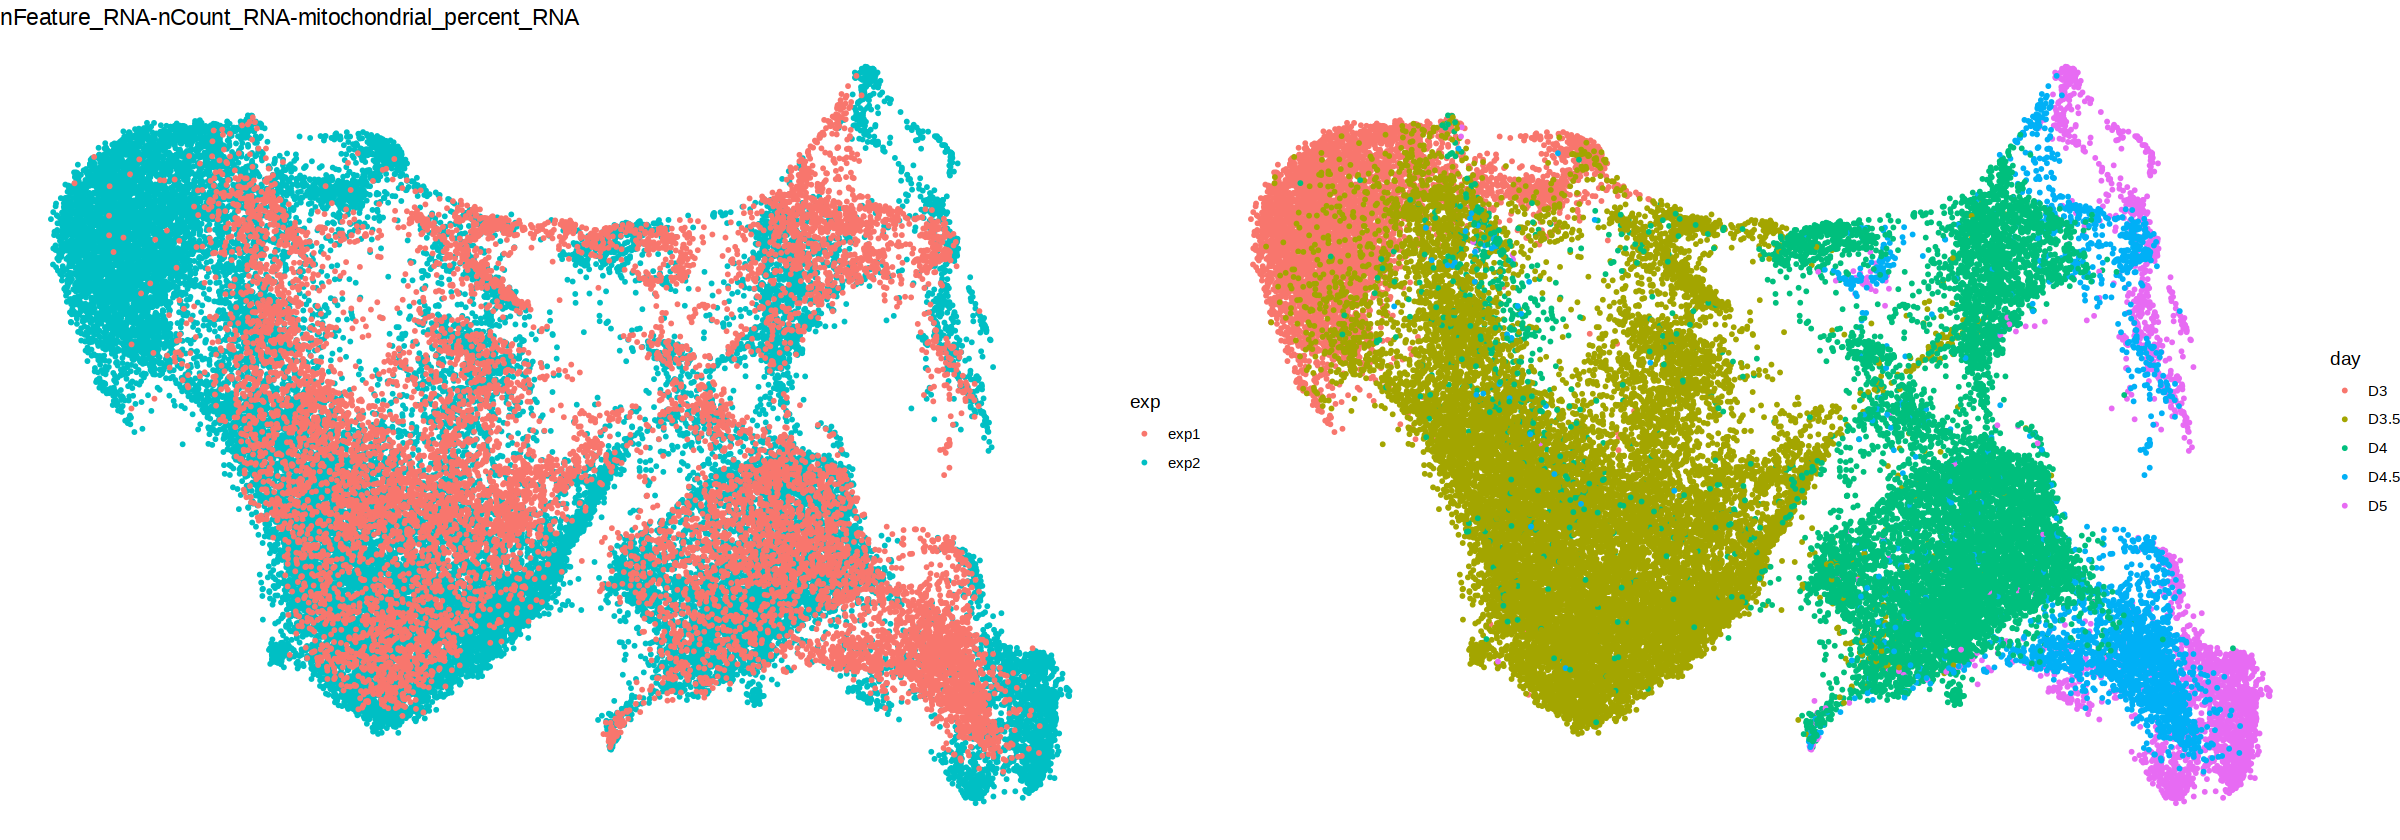

In [136]:
regress_test(c("nFeature_RNA", "nCount_RNA", "mitochondrial_percent_RNA"))

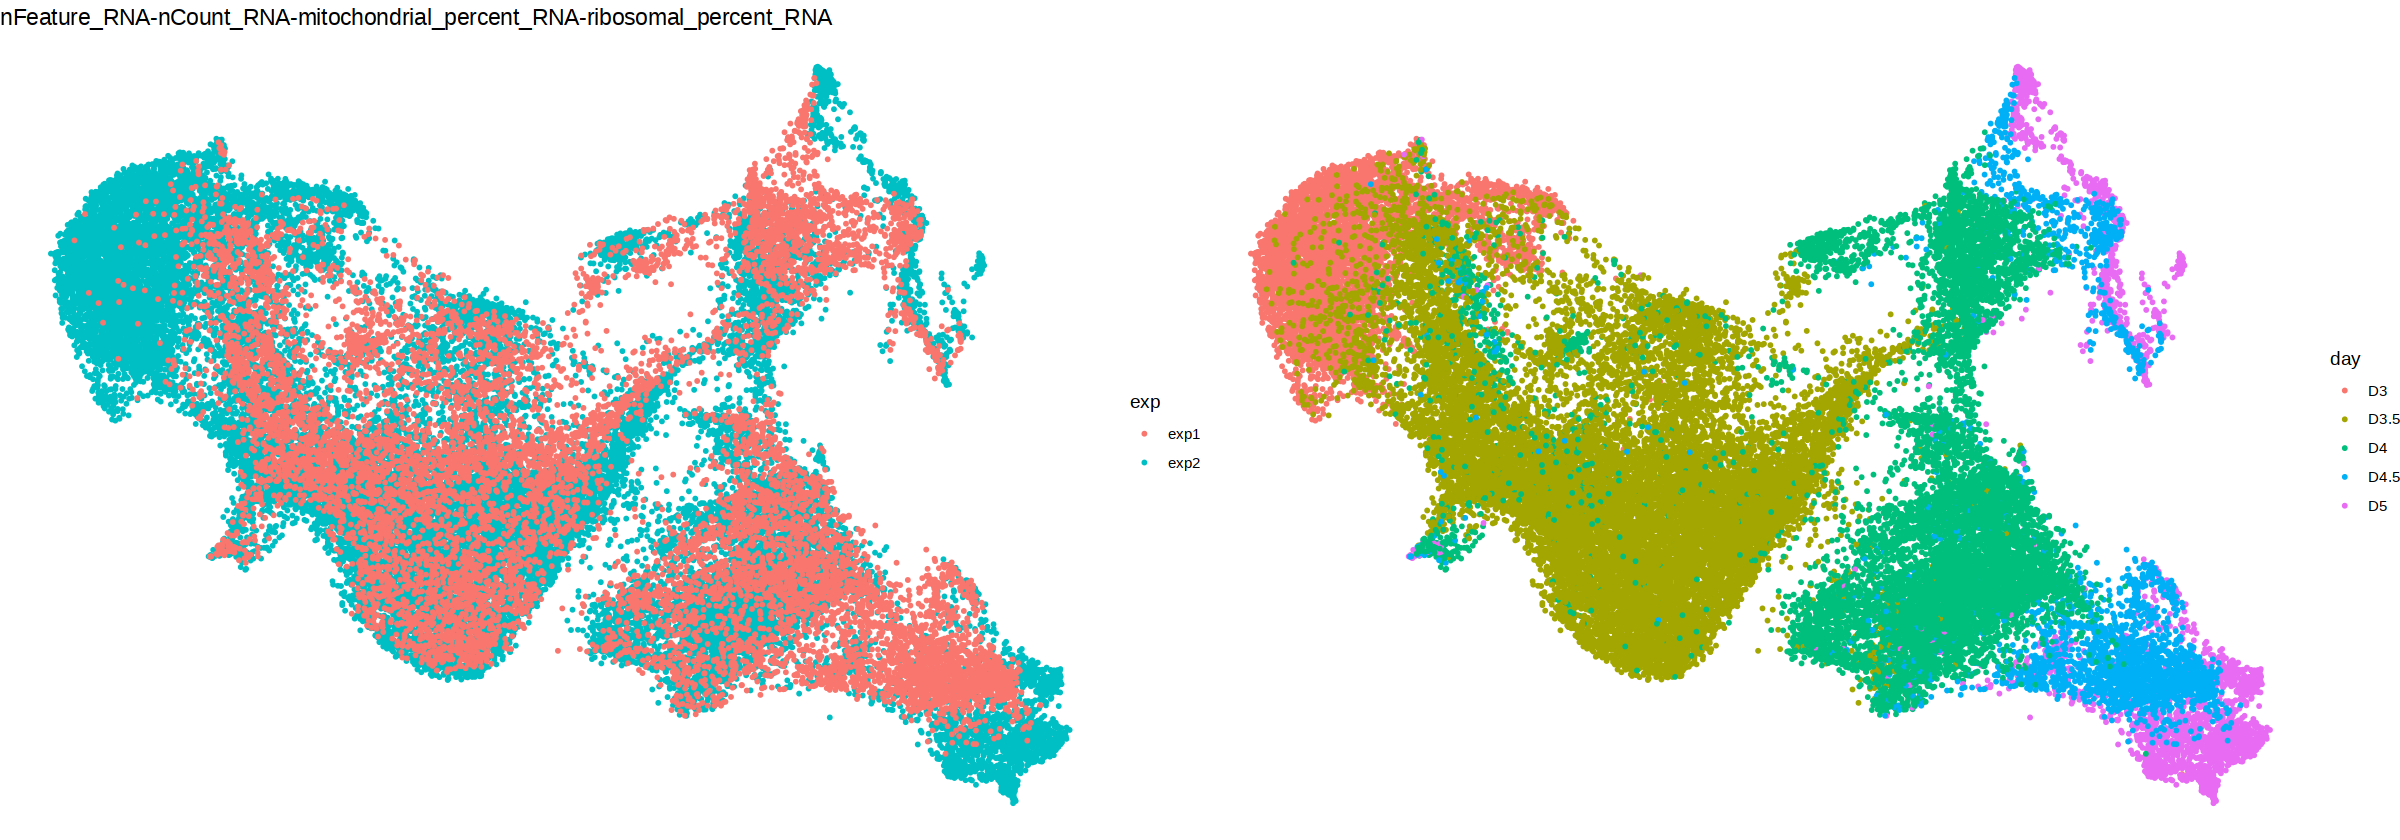

In [137]:
regress_test(c("nFeature_RNA", "nCount_RNA", "mitochondrial_percent_RNA", "ribosomal_percent_RNA"))

In [1]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code/rna/regression"

In [43]:
test = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/differential/pseudobulk/celltype/parsed/marker_genes_filtered.txt.gz')

In [45]:
head(test)

celltype,gene,score
<chr>,<chr>,<dbl>
Epiblast,Acsl4,1
Epiblast,Cdh9,1
Epiblast,Chd9,1
Epiblast,Dnajc6,1
Epiblast,Far2,1
Epiblast,Fut9,1


In [44]:
lapply(unique(test$celltype), function(x){
paste0(x, ": ", nrow(test[celltype==x]), ' genes')
})

[[1]]
[1] "Epiblast: 260 genes"

[[2]]
[1] "Primitive_Streak: 103 genes"

[[3]]
[1] "Caudal_epiblast: 63 genes"

[[4]]
[1] "PGC: 212 genes"

[[5]]
[1] "Anterior_Primitive_Streak: 189 genes"

[[6]]
[1] "Notochord: 799 genes"

[[7]]
[1] "Def._endoderm: 132 genes"

[[8]]
[1] "Gut: 126 genes"

[[9]]
[1] "Nascent_mesoderm: 107 genes"

[[10]]
[1] "Mixed_mesoderm: 65 genes"

[[11]]
[1] "Intermediate_mesoderm: 49 genes"

[[12]]
[1] "Caudal_Mesoderm: 118 genes"

[[13]]
[1] "Paraxial_mesoderm: 150 genes"

[[14]]
[1] "Somitic_mesoderm: 137 genes"

[[15]]
[1] "Pharyngeal_mesoderm: 129 genes"

[[16]]
[1] "Cardiomyocytes: 503 genes"

[[17]]
[1] "Allantois: 243 genes"

[[18]]
[1] "ExE_mesoderm: 81 genes"

[[19]]
[1] "Mesenchyme: 270 genes"

[[20]]
[1] "Haematoendothelial_progenitors: 209 genes"

[[21]]
[1] "Endothelium: 562 genes"

[[22]]
[1] "Blood_progenitors_1: 238 genes"

[[23]]
[1] "Blood_progenitors_2: 230 genes"

[[24]]
[1] "Erythroid1: 248 genes"

[[25]]
[1] "Erythroid2: 291 genes"

[[26]]
[1] "Erythroid3: 344 genes"

[[27]]
[1] "NMP: 123 genes"

[[28]]
[1] "Rostral_neurectoderm: 73 genes"

[[29]]
[1] "Caudal_neurectoderm: 301 genes"

[[30]]
[1] "Neural_crest: 145 genes"

[[31]]
[1] "Forebrain_Midbrain_Hindbrain: 240 genes"

[[32]]
[1] "Spinal_cord: 176 genes"

[[33]]
[1] "Surface_ectoderm: 141 genes"

[[34]]
[1] "Visceral_endoderm: 304 genes"

[[35]]
[1] "ExE_endoderm: 686 genes"

[[36]]
[1] "ExE_ectoderm: 313 genes"

[[37]]
[1] "Parietal_endoderm: 458 genes"

In [47]:
test = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/differential/pseudobulk/celltype/PeakMatrix/parsed/markers_filt.txt.gz')

In [50]:
head(test)

celltype,feature,score,logFC
<chr>,<chr>,<dbl>,<dbl>
Epiblast,chr10:100111058-100111658,0.94,3.71
Epiblast,chr10:103225272-103225872,0.97,3.64
Epiblast,chr10:103407173-103407773,0.94,3.86
Epiblast,chr10:105110047-105110647,0.89,3.49
Epiblast,chr10:106461140-106461740,0.86,4.16
Epiblast,chr10:107912061-107912661,0.91,3.59


In [48]:
lapply(unique(test$celltype), function(x){
paste0(x, ": ", nrow(test[celltype==x]), ' Regions')
})

[[1]]
[1] "Epiblast: 5682 Regions"

[[2]]
[1] "Primitive_Streak: 2920 Regions"

[[3]]
[1] "Caudal_epiblast: 1566 Regions"

[[4]]
[1] "PGC: 8417 Regions"

[[5]]
[1] "Anterior_Primitive_Streak: 7390 Regions"

[[6]]
[1] "Notochord: 7383 Regions"

[[7]]
[1] "Def._endoderm: 4769 Regions"

[[8]]
[1] "Gut: 4727 Regions"

[[9]]
[1] "Nascent_mesoderm: 4737 Regions"

[[10]]
[1] "Mixed_mesoderm: 4296 Regions"

[[11]]
[1] "Intermediate_mesoderm: 2713 Regions"

[[12]]
[1] "Caudal_Mesoderm: 4755 Regions"

[[13]]
[1] "Paraxial_mesoderm: 6467 Regions"

[[14]]
[1] "Somitic_mesoderm: 5906 Regions"

[[15]]
[1] "Pharyngeal_mesoderm: 3279 Regions"

[[16]]
[1] "Cardiomyocytes: 6783 Regions"

[[17]]
[1] "Allantois: 7031 Regions"

[[18]]
[1] "ExE_mesoderm: 4666 Regions"

[[19]]
[1] "Mesenchyme: 6364 Regions"

[[20]]
[1] "Haematoendothelial_progenitors: 6524 Regions"

[[21]]
[1] "Endothelium: 9922 Regions"

[[22]]
[1] "Blood_progenitors_1: 5965 Regions"

[[23]]
[1] "Blood_progenitors_2: 7497 Regions"

[[24]]
[1] "Erythroid1: 8627 Regions"

[[25]]
[1] "Erythroid2: 8784 Regions"

[[26]]
[1] "Erythroid3: 8670 Regions"

[[27]]
[1] "NMP: 6161 Regions"

[[28]]
[1] "Rostral_neurectoderm: 3764 Regions"

[[29]]
[1] "Neural_crest: 14123 Regions"

[[30]]
[1] "Forebrain_Midbrain_Hindbrain: 7067 Regions"

[[31]]
[1] "Spinal_cord: 8194 Regions"

[[32]]
[1] "Surface_ectoderm: 4265 Regions"

[[33]]
[1] "Visceral_endoderm: 9063 Regions"

[[34]]
[1] "ExE_endoderm: 13553 Regions"

[[35]]
[1] "ExE_ectoderm: 8905 Regions"

[[36]]
[1] "Parietal_endoderm: 15037 Regions"

In [49]:
head(test[order(-score, -logFC)][celltype=='Endothelium'], 100)

celltype,feature,score,logFC
<chr>,<chr>,<dbl>,<dbl>
Endothelium,chr3:115708991-115709591,1,7.14
Endothelium,chr2:11239403-11240003,1,6.87
Endothelium,chrX:18461140-18461740,1,6.65
Endothelium,chr12:36521691-36522291,1,6.64
Endothelium,chr9:70977338-70977938,1,6.61
Endothelium,chr7:105228036-105228636,1,6.60
Endothelium,chr16:42676582-42677182,1,6.57
Endothelium,chr13:60936393-60936993,1,6.55
Endothelium,chr18:83740431-83741031,1,6.48
